<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/Transfer_Learning_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1 — Why Training CNN from Scratch is Hard

Before using Transfer Learning, we must first understand **why we do not usually train a CNN from scratch for every new image problem**.

---

## 1. The Core Practical Problem

Suppose we want to build an image classifier for:

- Cats vs Dogs
- Medical image diagnosis
- Defect detection
- Plant disease classification

A natural first thought is:

> "Why not just design a CNN and train it from the beginning?"

In theory, this is possible.

In practice, it is often difficult because deep CNNs require:

- **many parameters**
- **large labeled datasets**
- **high computation**
- **long training time**
- **careful tuning**

---

## 2. Why CNNs Become Large

A CNN learns many filters across multiple layers.

Early layers may learn:

- edges
- corners
- textures

Middle layers may learn:

- shapes
- repeated patterns
- object parts

Deep layers may learn:

- class-specific structures
- semantic patterns

As depth increases, the network becomes more powerful, but also more expensive to train.

Even though CNNs are more parameter-efficient than fully connected ANNs for images, modern CNNs still contain **millions of trainable parameters**.

For example:

- A small custom CNN may have thousands to millions of parameters
- ResNet18 has around **11 million parameters**
- Larger models can have tens or hundreds of millions of parameters

This means the model has a huge number of values to learn from data.

---

## 3. Why Data Requirement Becomes a Problem

A model with many parameters needs enough data to learn stable patterns.

If the dataset is too small:

- the model may memorize training images
- validation accuracy may remain poor
- the model may fail on new images

This is called **overfitting**.

For image tasks, collecting labeled data is expensive because:

- images must be gathered
- labels must be correct
- classes must be balanced
- data must capture real-world variation

Example variations in Cats vs Dogs:

- pose
- lighting
- background
- camera angle
- partial visibility
- breed differences

A CNN trained from scratch must learn all these variations from the available dataset.

---

## 4. Why Computation Becomes Heavy

Training a deep CNN from scratch involves repeated forward and backward passes over many batches.

This requires:

- GPU memory
- training time
- tuning learning rate
- regularization
- debugging unstable training

If the model is deep and the dataset is large, training can take a long time.

If the dataset is small, the model may still not generalize well, even after spending a lot of compute.

So the challenge is not only:

> "Can we train the model?"

The real question is:

> "Can we train it well enough, fast enough, and with enough data?"

---

## 5. The Main Idea Behind Transfer Learning

Instead of starting from random weights, we often start from a model that has **already learned useful visual patterns** from a large image dataset.

Such a pretrained model has already learned features like:

- edges
- textures
- curves
- object parts
- spatial hierarchies

Then we adapt that model to our new task.

This is called **Transfer Learning**.

So the motivation is simple:

- training from scratch is expensive
- data is often limited
- pretrained models already know useful image features
- we reuse that knowledge instead of learning everything again

---

## 6. Intuition Summary

Training from scratch is hard because deep CNNs need:

1. many trainable parameters  
2. lots of labeled data  
3. significant compute  
4. careful tuning  
5. protection against overfitting  

This is why Transfer Learning is so important in real-world deep learning workflows.

---

## 7. Bridge to Next Section

Now the natural question becomes:

> If training from scratch is difficult, how can a pretrained model help us?

That leads directly to the next topic:

# What is Transfer Learning?

In [ ]:
# SECTION 1 CODE — Why Training CNN from Scratch is Hard

import torch
import torch.nn as nn
from torchvision import models

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.6.0.dev20241112+cu121
CUDA available: True
Using device: cuda


In [ ]:
# A small custom CNN for image classification

class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),   # (B, 16, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                            # (B, 16, 64, 64)

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),  # (B, 32, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                            # (B, 32, 32, 32)

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # (B, 64, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)                                             # (B, 64, 16, 16)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                           # (B, 64*16*16)
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        print("Input shape:", x.shape)
        x = self.features[0](x)
        print("After Conv1:", x.shape)
        x = self.features[1](x)
        x = self.features[2](x)
        print("After Pool1:", x.shape)

        x = self.features[3](x)
        print("After Conv2:", x.shape)
        x = self.features[4](x)
        x = self.features[5](x)
        print("After Pool2:", x.shape)

        x = self.features[6](x)
        print("After Conv3:", x.shape)
        x = self.features[7](x)
        x = self.features[8](x)
        print("After Pool3:", x.shape)

        x = self.classifier[0](x)
        print("After Flatten:", x.shape)
        x = self.classifier[1](x)
        print("After FC1:", x.shape)
        x = self.classifier[2](x)
        x = self.classifier[3](x)
        print("Output logits shape:", x.shape)
        return x

small_cnn = SmallCNN(num_classes=2).to(device)

dummy_batch = torch.randn(4, 3, 128, 128).to(device)
output = small_cnn(dummy_batch)

Input shape: torch.Size([4, 3, 128, 128])
After Conv1: torch.Size([4, 16, 128, 128])
After Pool1: torch.Size([4, 16, 64, 64])
After Conv2: torch.Size([4, 32, 64, 64])
After Pool2: torch.Size([4, 32, 32, 32])
After Conv3: torch.Size([4, 64, 32, 32])
After Pool3: torch.Size([4, 64, 16, 16])
After Flatten: torch.Size([4, 16384])
After FC1: torch.Size([4, 128])
Output logits shape: torch.Size([4, 2])


In [ ]:
# Function to count total and trainable parameters

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

small_total, small_trainable = count_parameters(small_cnn)

print("SmallCNN total parameters:", small_total)
print("SmallCNN trainable parameters:", small_trainable)

SmallCNN total parameters: 2121122
SmallCNN trainable parameters: 2121122


In [ ]:
# Load ResNet18 without focusing on transfer learning details yet
# We only inspect its size here

resnet18 = models.resnet18(weights=None).to(device)

resnet_total, resnet_trainable = count_parameters(resnet18)

print("ResNet18 total parameters:", resnet_total)
print("ResNet18 trainable parameters:", resnet_trainable)

ResNet18 total parameters: 11689512
ResNet18 trainable parameters: 11689512


In [ ]:
# Pass a dummy tensor through ResNet18 and inspect output shape

dummy_batch = torch.randn(4, 3, 224, 224).to(device)
print("ResNet18 input shape:", dummy_batch.shape)

resnet_output = resnet18(dummy_batch)
print("ResNet18 output logits shape:", resnet_output.shape)

ResNet18 input shape: torch.Size([4, 3, 224, 224])
ResNet18 output logits shape: torch.Size([4, 1000])


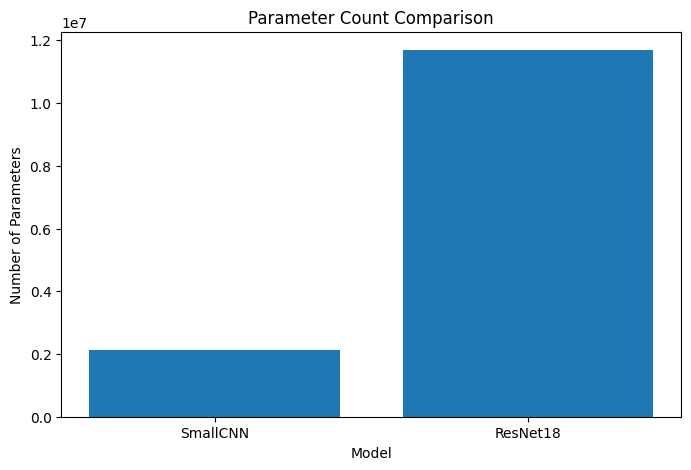

SmallCNN: 2,121,122 parameters
ResNet18: 11,689,512 parameters


In [ ]:
import matplotlib.pyplot as plt

model_names = ["SmallCNN", "ResNet18"]
param_counts = [small_total, resnet_total]

plt.figure(figsize=(8, 5))
plt.bar(model_names, param_counts)
plt.title("Parameter Count Comparison")
plt.ylabel("Number of Parameters")
plt.xlabel("Model")
plt.show()

for name, count in zip(model_names, param_counts):
    print(f"{name}: {count:,} parameters")

## Concept-Check Questions

1. Why is image classification not truly “simple” even when there are only two classes like cats and dogs?

2. What does it mean when we say a CNN has millions of parameters?

3. Why can a deep CNN overfit when the dataset is small?

4. Why is training from scratch computationally expensive?

5. What practical problem does Transfer Learning try to solve?

# SECTION 2 — What is Transfer Learning

In the previous section we saw that training a CNN from scratch can be difficult because:

- CNNs contain millions of parameters
- Large labeled datasets are required
- Training is computationally expensive
- Models can easily overfit when data is limited

A practical solution widely used in deep learning is **Transfer Learning**.

---

# 1. The Core Idea of Transfer Learning

Transfer Learning means:

> Reusing knowledge learned from one task to solve another related task.

Instead of training a CNN from random weights, we start from a **pretrained model** that has already learned useful visual features.

Example:

A CNN trained on **ImageNet** has already learned to detect:

- edges
- textures
- corners
- color gradients
- shapes
- object parts

These patterns are common across many image tasks.

Therefore, instead of learning these features again, we reuse them.

---

# 2. Example: ImageNet Pretrained Models

ImageNet is a large dataset containing:

- ~1.2 million images
- 1000 object classes

Many famous CNN architectures were trained on ImageNet:

- ResNet
- VGG
- AlexNet
- EfficientNet
- MobileNet

These pretrained models already contain **rich visual representations**.

When we apply transfer learning, we reuse those representations.

---

# 3. Intuition of Feature Reuse

CNN features form a hierarchy.

Early layers learn **general features**

- edges
- gradients
- simple textures

Middle layers learn **combinations**

- shapes
- object parts
- repeated structures

Deep layers learn **task-specific concepts**

- faces
- wheels
- animals
- textures

This hierarchy is extremely useful.

Even if our new task is different, early visual features are still valuable.

Example:

Edges learned for detecting **cars** are also useful for detecting **dogs**.

---

# 4. Two Main Strategies in Transfer Learning

There are two common approaches.

## Strategy 1 — Feature Extraction

We keep most of the pretrained network **fixed** and only train a small classifier on top.

Steps:

1. Load pretrained model
2. Freeze convolution layers
3. Replace final classification layer
4. Train the new classifier

The pretrained CNN acts as a **feature extractor**.

---

## Strategy 2 — Fine-Tuning

Instead of freezing all layers, we allow some deeper layers to update during training.

Steps:

1. Load pretrained model
2. Replace final classification layer
3. Train classifier first
4. Unfreeze some deeper layers
5. Continue training with small learning rate

This allows the model to slightly adapt its representations to the new dataset.

---

# 5. Freezing Layers

Freezing a layer means:

> We prevent its weights from updating during training.

In PyTorch this is done by setting:
param.requires_grad = False



When layers are frozen:

- gradients are not computed
- parameters remain fixed
- training becomes faster
- fewer parameters must be optimized

---

# 6. Why Transfer Learning Works So Well

Transfer learning works because:

- early visual features are universal
- pretrained models learned from massive datasets
- our dataset may be small
- we only need to learn the task-specific mapping

This dramatically reduces the amount of data and training time required.

---

# 7. Transfer Learning in Practice

Typical workflow:

1. Load pretrained CNN (e.g., ResNet18)
2. Replace final layer
3. Freeze most layers
4. Train classifier on new dataset
5. Optionally fine-tune deeper layers

This approach is used in:

- medical imaging
- autonomous driving
- defect detection
- satellite imagery
- wildlife monitoring
- product recognition

---

# Bridge to Next Section

Now that we understand transfer learning conceptually, the next step is:

# How do we prepare an image dataset for training?

In the next section we will build the **data pipeline**:

- image loading
- transformations
- batching with DataLoader

In [ ]:
# SECTION 2 CODE — Loading a pretrained CNN

import torch
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
print("Final layer before modification:")
print(model.fc)

Final layer before modification:
Linear(in_features=512, out_features=1000, bias=True)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11689512
Trainable parameters: 11689512


In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters after freezing:", trainable_params)

Trainable parameters after freezing: 0


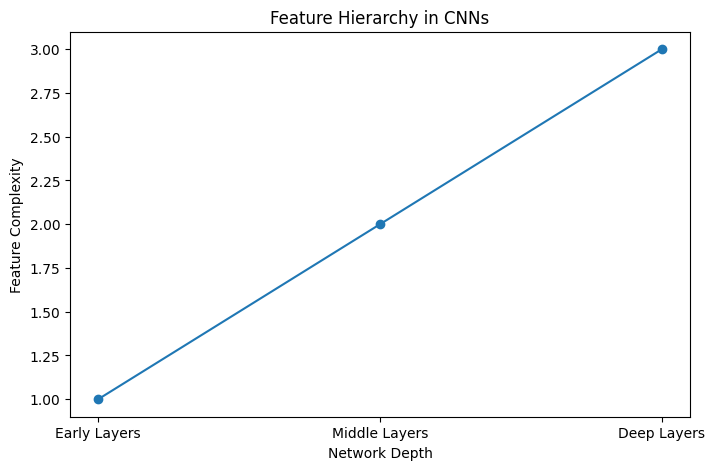

In [ ]:
import matplotlib.pyplot as plt

layers = ["Early Layers", "Middle Layers", "Deep Layers"]
features = [1, 2, 3]

plt.figure(figsize=(8,5))
plt.plot(layers, features, marker='o')

plt.title("Feature Hierarchy in CNNs")
plt.ylabel("Feature Complexity")
plt.xlabel("Network Depth")

plt.show()

## Concept Check Questions

1. What is the main idea behind transfer learning?

2. Why are early CNN layers reusable across many image tasks?

3. What does freezing a layer mean in neural network training?

4. What is the difference between feature extraction and fine-tuning?

5. Why do pretrained models reduce training time?

# SECTION 3 — Preparing Image Dataset

Before training a pretrained CNN, we must prepare the image dataset correctly.

In real deep learning workflows, many training issues come not from the model, but from the **data pipeline**.

So this section is extremely important.

---

## 1. Why Data Preparation Matters

A CNN does not read images the way humans do.

For a CNN, an image must be converted into a structured tensor with:

- fixed size
- numeric values
- correct channel order
- consistent normalization

If the pipeline is incorrect, then:

- tensor shapes may break
- images may appear distorted
- model performance may degrade
- training may become unstable

So before model training, we must ensure:

1. images are loaded correctly  
2. labels are assigned correctly  
3. transformations are applied correctly  
4. batches are formed correctly  

---

## 2. Typical Folder Structure for Image Classification

For a simple Cats vs Dogs classification task, we usually keep data in this form:

```text
data/
    train/
        cats/
            cat1.jpg
            cat2.jpg
            ...
        dogs/
            dog1.jpg
            dog2.jpg
            ...
    val/
        cats/
            ...
        dogs/
            ...
    test/
        cats/
            ...
        dogs/
            ...


---

## 2. Light conceptual explanation

This is the section where students should understand that **deep learning starts with disciplined data handling**.

A useful classroom analogy:

A CNN is like a factory machine that only accepts inputs in one standard format.

If you feed it:

- different sizes
- wrong arrangement
- inconsistent values

the machine cannot work properly.

So the dataset pipeline is like the **preprocessing unit** that standardizes everything before it enters the model.

Another intuitive point:

Humans can recognize a cat whether the image is large, small, slightly rotated, or placed differently.

A model must be trained to become robust to such variation.

That is why augmentation helps.

---

## 3. Runnable PyTorch code

Below is a clean practical pipeline using `ImageFolder`, transforms, and `DataLoader`.

### Markdown note for dataset path

```markdown
## Important Note

Update the dataset path according to your machine.

Expected structure:

data/
    train/
        cats/
        dogs/
    val/
        cats/
        dogs/
    test/
        cats/
        dogs/

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Update this path according to your local dataset folder
data_dir = "data"

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

In [ ]:
# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Train transform:\n", train_transform)
print("\nEvaluation transform:\n", eval_transform)

In [ ]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=eval_transform)

print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))
print("Number of test images:", len(test_dataset))

## Concept-Check Questions

1. Why do we resize all images to a fixed size before feeding them to the CNN?

2. Why do we use different transforms for training and validation data?

3. What is the role of `ImageFolder` in PyTorch?

4. What is the difference between a dataset and a DataLoader?

5. If a batch shape is `(16, 3, 224, 224)`, what does each dimension mean?

6. Why should we inspect `class_to_idx` before training?

7. Why do pretrained ResNet models typically use ImageNet normalization values?